## Linear Regression, Regularization, and Constrained Optimization

Oskar Andersson - oa222jq

In this notebook, we explore linear regression from several perspectives:

- Ordinary least squares (OLS)
- Gradient descent optimization
- L2 (ridge) and L1 (lasso) regularization
- Constrained optimization using Lagrange multipliers
- Slack-variable formulations
- Extension to multivariate regression

The goal is to reproduce and understand the MATLAB implementation using Python, while also highlighting the differences between these approaches.

## Repeat gradient descent with two (and more) variables

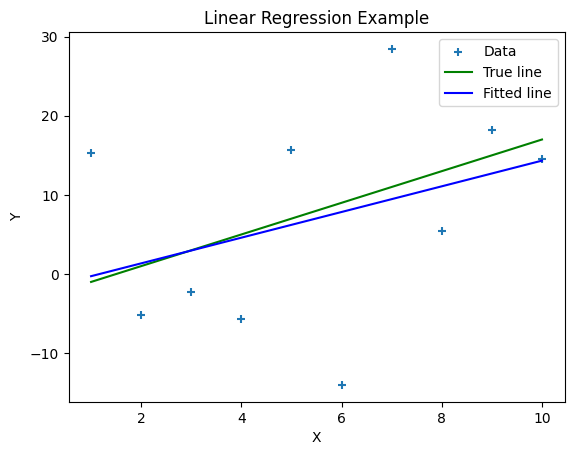

In [262]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

# Equivalent of rng(1)
np.random.seed(1)

# Parameters
N = 10
a0 = 2
b0 = -3

# Data generation
X = np.arange(1, N + 1)          # MATLAB: 1:N
noise = np.random.normal(0, 10, N)
Y = a0 * X + b0 + noise

# Reshape X for sklearn (must be 2D)
X_reshaped = X.reshape(-1, 1)

# Scatter plot
plt.scatter(X, Y, marker='+', label='Data')

# True line
plt.plot(X, a0 * X + b0, color='g', label='True line')

# Linear regression (MATLAB fitlm equivalent)
model = LinearRegression()
model.fit(X_reshaped, Y)

# Extract coefficients
a_hat = model.coef_[0]
b_hat = model.intercept_

# Plot fitted line
plt.plot(X, a_hat * X + b_hat, color='b', label='Fitted line')

# Cosmetics
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Example')

plt.show()

### Ordinary Least Squares (OLS)

We start by fitting a linear model of the form:

$$
y = ax + b
$$

using noisy data. The least-squares solution minimizes the residual sum of squares (RSS):

$$
RSS(a,b) = \sum_i (y_i - (ax_i + b))^2
$$

We compare:
- the true underlying model
- the fitted model from the data

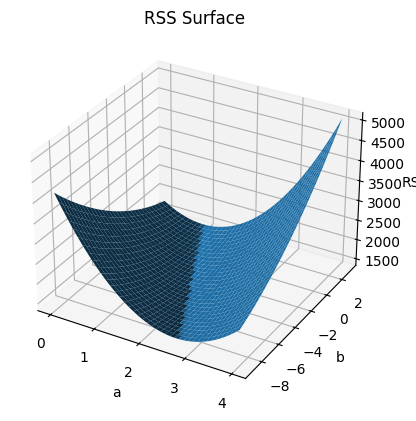

In [263]:
# Define RSS function
def rss2(a, b, X, Y):
    return np.sum((Y - (a * X + b))**2)

# Parameter grid (same ranges as MATLAB)
a_vals = np.arange(a0 - 2, a0 + 2.1, 0.1)
b_vals = np.arange(b0 - 6, b0 + 6.1, 0.4)

A, B = np.meshgrid(a_vals, b_vals)

# Compute RSS over the grid (vectorized)
Z = np.zeros_like(A)

# Vectorized RSS computation
# reshape X for broadcasting
X_col = X.reshape(1, 1, -1)
Y_col = Y.reshape(1, 1, -1)

Z = np.sum((Y_col - (A[:, :, None] * X_col + B[:, :, None]))**2, axis=2)

# Plot 3D surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(A, B, Z)

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_zlabel('RSS')
ax.set_title('RSS Surface')

plt.show()

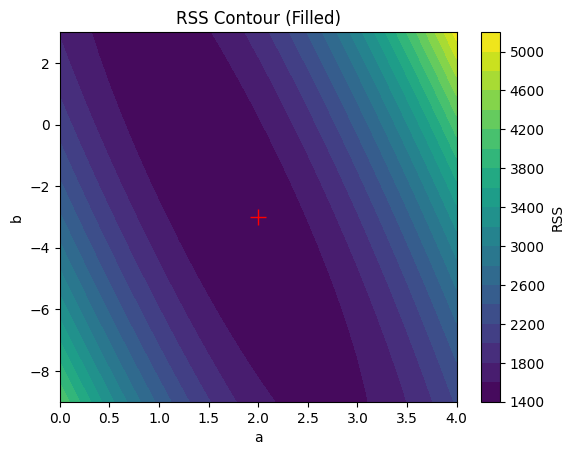

In [264]:
plt.figure()

plt.contourf(A, B, Z, levels=20)
plt.colorbar(label='RSS')

plt.plot(a0, b0, '+', color='red', markersize=12)

plt.xlabel('a')
plt.ylabel('b')
plt.title('RSS Contour (Filled)')

plt.show()

### Gradient Descent

Instead of solving OLS analytically, we now minimize the RSS using gradient descent.

This allows us to:
- visualize the optimization path
- understand convergence behavior
- later extend to cases where closed-form solutions are not available

The gradient of $RSS(a,b)$ for any $a, b$ is defiend as:

$$
\begin{aligned}

\nabla RSS(a,b) &= \left [ \frac{\partial RSS(a,b)}{\partial a}, \frac{\partial RSS(a,b)}{\partial b}\right ]^T\\
&= -2 \left [ \sum_{i=1}^{n}(y_i- a x_i-b)x_i, \sum_{i=1}^{n}(y_i- a x_i-b) \right ]^T 
\end{aligned}
$$

The gradient descent find the minimum.

[[ 2.         -3.        ]
 [ 1.5771962  -3.04857045]
 [ 1.98164659 -2.97844132]
 ...
 [ 1.62263137 -1.89588781]
 [ 1.62263133 -1.89588749]
 [ 1.62263128 -1.89588718]]


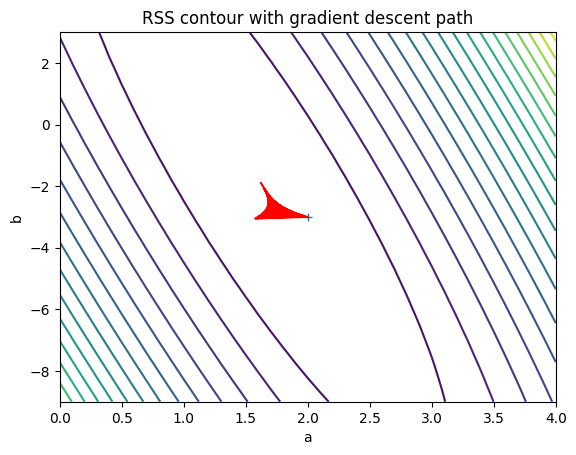

In [265]:
def grad_rss2(a, b, X, Y):
    r = Y - (a * X + b)
    da = -2 * np.sum(X * r)
    db = -2 * np.sum(r)
    return da, db

def grad_desc_rss2(K, a_init, b_init, learning_eps, X, Y, store_initial=True):
    a = a_init
    b = b_init

    as_list = [a] if store_initial else []
    bs_list = [b] if store_initial else []

    for _ in range(K):
        da, db = grad_rss2(a, b, X, Y)
        a = a - learning_eps * da
        b = b - learning_eps * db

        as_list.append(a)
        bs_list.append(b)

    return np.array(as_list), np.array(bs_list)

K = 1000
learning_eps = 0.0025

as_orig, bs_orig = grad_desc_rss2(K, a0, b0, learning_eps, X, Y)

print(np.column_stack((as_orig, bs_orig)))

plt.figure()
plt.contour(A, B, Z, levels=20)
plt.plot(a0, b0, '+')
plt.plot(as_orig, bs_orig, 'r-')
plt.xlabel('a')
plt.ylabel('b')
plt.title('RSS contour with gradient descent path')
plt.show()

Orig: a=1.62 b=-1.90 loss=1406.49


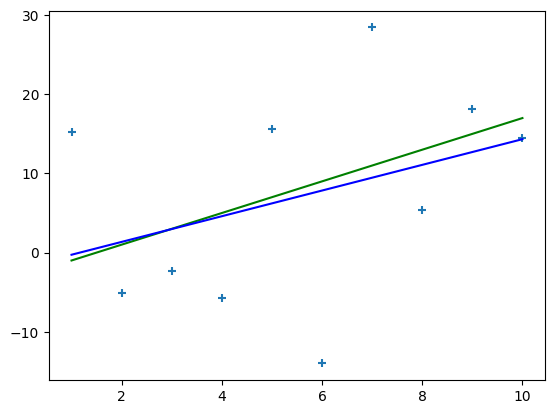

In [266]:
a_orig = as_orig[K]
b_orig = bs_orig[K]

print("Orig: a=%.2f b=%.2f loss=%.2f" % (a_orig, b_orig, rss2(a_orig, b_orig, X, Y)))

plt.figure()
plt.scatter(X, Y, marker='+')
plt.plot(X, a0 * X + b0, color='g')
plt.plot(X, a_orig * X + b_orig, color='b')
plt.show()

The optimization path shows how the parameters move through the loss landscape.

We observe:
- convergence toward the minimum
- dependence on learning rate
- potential zig-zag behavior due to gradient direction

## Regularization with the $L^2$ Norm

### L2 Regularization (Ridge)

We now add a penalty term:

$$
RSS + \alpha (a^2 + b^2)
$$

This discourages large parameter values and improves stability.

Key effect:
- parameters are shrunk toward zero
- the solution becomes more stable under noise

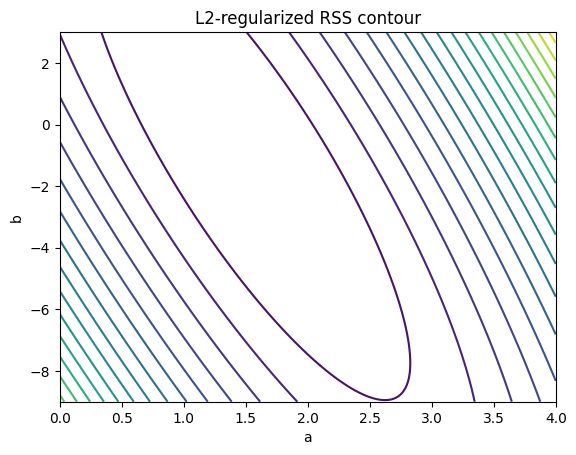

In [267]:
import numpy as np
import matplotlib.pyplot as plt

# alpha = 1 (last assignment wins, same as MATLAB)
alpha = 1

# L2-regularized objective
def fL2(a, b, X, Y, alpha):
    return rss2(a, b, X, Y) + alpha * (a**2 + b**2)

# Grid (match MATLAB ranges and step size)
a_vals = np.arange(a0 - 2, a0 + 2 + 0.01, 0.01)
b_vals = np.arange(b0 - 6, b0 + 6 + 0.01, 0.01)

A, B = np.meshgrid(a_vals, b_vals)

# Evaluate function on grid (same style as earlier for fidelity)
Z = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        Z[i, j] = fL2(A[i, j], B[i, j], X, Y, alpha)

# Contour plot (equivalent to plot3d(..., false))
plt.figure()
plt.contour(A, B, Z, levels=20)

plt.xlabel('a')
plt.ylabel('b')
plt.title('L2-regularized RSS contour')

plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^2}(a,b) 
&= \left [ \frac{\partial RSS_{L^2}(a,b)}{\partial a}, \frac{\partial RSS_{L^2}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +2\alpha a, \frac{\partial RSS(a,b)}{\partial b}+2\alpha b\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2 \alpha a, -2 \sum_{i=1}^{n}(y_i- a x_i-b) +2 \alpha b\right ]^T 
\end{aligned}
$$

[[ 2.         -3.        ]
 [ 1.5671962  -3.03357045]
 [ 1.97893561 -2.94627347]
 ...
 [ 1.52260982 -1.22342094]
 [ 1.52260982 -1.22342093]
 [ 1.52260982 -1.22342093]]


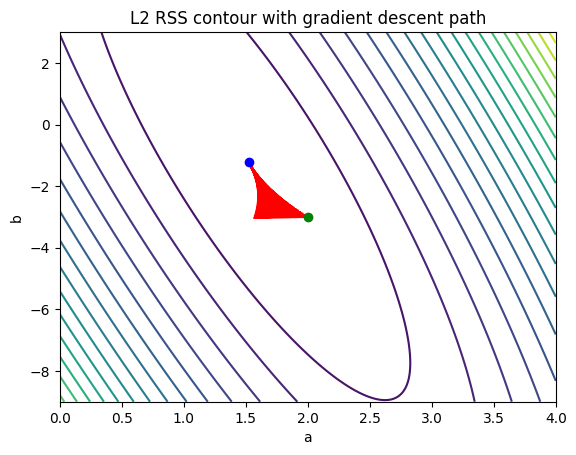

In [268]:
def grad_rss2_L2(a, b, X, Y, alpha):
    da, db = grad_rss2(a, b, X, Y)
    da += 2 * alpha * a
    db += 2 * alpha * b
    return da, db

def grad_desc_rss2_L2(K, a_init, b_init, learning_eps, X, Y, alpha):
    a = a_init
    b = b_init

    as_list = [a]
    bs_list = [b]

    for _ in range(K):
        da, db = grad_rss2_L2(a, b, X, Y, alpha)
        a = a - learning_eps * da
        b = b - learning_eps * db

        as_list.append(a)
        bs_list.append(b)

    return np.array(as_list), np.array(bs_list)

K = 1000
learning_eps = 0.0025

as_L2, bs_L2 = grad_desc_rss2_L2(K, a0, b0, learning_eps, X, Y, alpha)

print(np.column_stack((as_L2, bs_L2)))

plt.figure()
plt.contour(A, B, Z, levels=20)
plt.plot(as_L2, bs_L2, 'r-')
plt.plot(as_L2[0], bs_L2[0], 'go')
plt.plot(as_L2[K], bs_L2[K], 'bo')
plt.xlabel('a')
plt.ylabel('b')
plt.title('L2 RSS contour with gradient descent path')
plt.show()

L2: a=1.52 b=-1.22 loss=1407.47


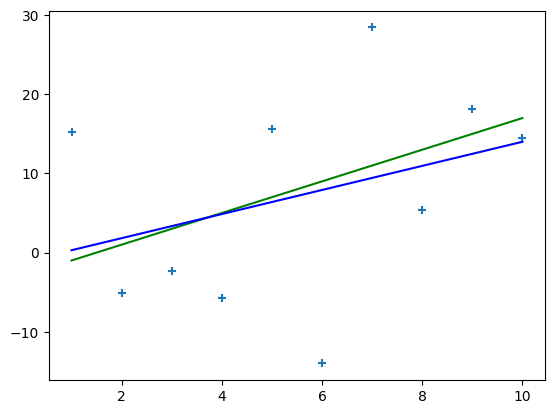

In [269]:
a_L2 = as_L2[K]
b_L2 = bs_L2[K]

print(f"L2: a={a_L2:.2f} b={b_L2:.2f} loss={rss2(a_L2, b_L2, X, Y):.2f}")

plt.figure()
plt.scatter(X, Y, marker='+')
plt.plot(X, a0 * X + b0, color='g')
plt.plot(X, a_L2 * X + b_L2, color='b')
plt.show()

### Centered L2 Regularization

Instead of shrinking toward zero, we now shrink toward a reference point \((a_0, b_0)\):

\[
RSS + \alpha((a-a_0)^2 + (b-b_0)^2)
\]

This can be interpreted as a prior belief about the parameters.

## Parameter Tying

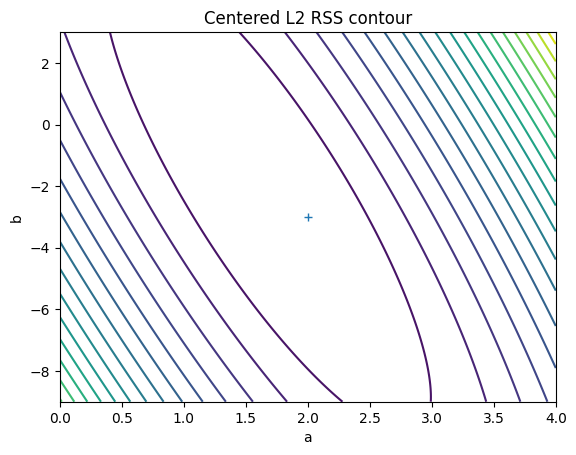

In [270]:
alpha = 1

# Centered L2 objective
def fL2_centered(a, b, X, Y, alpha, a0, b0):
    return rss2(a, b, X, Y) + alpha * ((a - a0)**2 + (b - b0)**2)

# Grid (match MATLAB exactly)
a_vals = np.arange(a0 - 2, a0 + 2 + 0.01, 0.01)
b_vals = np.arange(b0 - 6, b0 + 6 + 0.01, 0.01)

A, B = np.meshgrid(a_vals, b_vals)

# Evaluate on grid
Z = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        Z[i, j] = fL2_centered(A[i, j], B[i, j], X, Y, alpha, a0, b0)

# Contour plot (MATLAB plot3d(..., false))
plt.figure()
plt.contour(A, B, Z, levels=20)

# Mark center (a0, b0) like MATLAB often implies
plt.plot(a0, b0, '+')

plt.xlabel('a')
plt.ylabel('b')
plt.title('Centered L2 RSS contour')

plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^2, a_0, b_0}(a,b) 
&= \left [ \frac{\partial RSS_{L^2, a_0, b_0}(a,b)}{\partial a}, \frac{\partial RSS_{L^2, a_0, b_0}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +2\alpha (a-a_0), \frac{\partial RSS(a,b)}{\partial b}+2\alpha (b - b_0)\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2 \alpha (a-a_0), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +2 \alpha (b - b_0)\right ]^T 
\end{aligned}
$$

[[ 2.         -3.        ]
 [ 1.5771962  -3.04857045]
 [ 1.98376061 -2.97819847]
 ...
 [ 1.67576295 -2.2619138 ]
 [ 1.67576295 -2.2619138 ]
 [ 1.67576295 -2.2619138 ]]


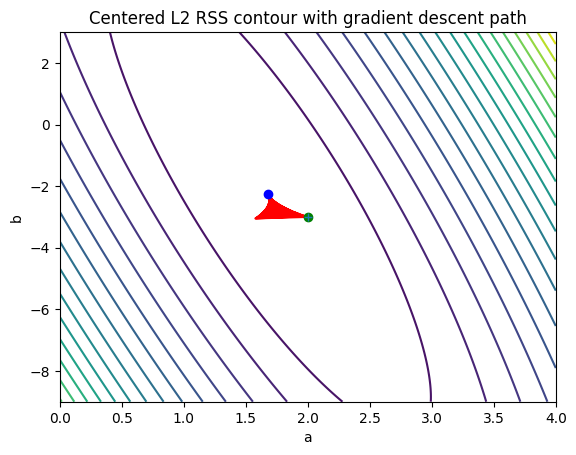

In [271]:
def grad_rss2_L2_centered(a, b, X, Y, alpha, a0, b0):
    da, db = grad_rss2(a, b, X, Y)
    da += 2 * alpha * (a - a0)
    db += 2 * alpha * (b - b0)
    return da, db

def grad_desc_generic(K, a_init, b_init, learning_eps, grad_f, store_initial=True):
    a = a_init
    b = b_init

    as_list = [a] if store_initial else []
    bs_list = [b] if store_initial else []

    for _ in range(K):
        da, db = grad_f(a, b)
        a = a - learning_eps * da
        b = b - learning_eps * db

        as_list.append(a)
        bs_list.append(b)

    return np.array(as_list), np.array(bs_list)

K = 1000
learning_eps = 0.0025

ffL2_centered = lambda a, b: grad_rss2_L2_centered(a, b, X, Y, alpha, a0, b0)

as_centered_L2, bs_centered_L2 = grad_desc_generic(
    K, a0, b0, learning_eps, ffL2_centered, True
)

print(np.column_stack((as_centered_L2, bs_centered_L2)))

plt.figure()
plt.contour(A, B, Z, levels=20)
plt.plot(as_centered_L2, bs_centered_L2, 'r-')
plt.plot(as_centered_L2[0], bs_centered_L2[0], 'go')
plt.plot(as_centered_L2[K], bs_centered_L2[K], 'bo')
plt.plot(a0, b0, '+')
plt.xlabel('a')
plt.ylabel('b')
plt.title('Centered L2 RSS contour with gradient descent path')
plt.show()


L2: a=1.68 b=-2.26 loss=1406.78


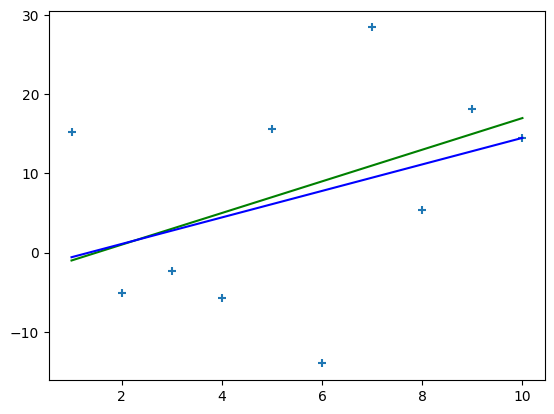

In [272]:
a_centered_L2 = as_centered_L2[K]
b_centered_L2 = bs_centered_L2[K]

print(
    f"L2: a={a_centered_L2:.2f} b={b_centered_L2:.2f} "
    f"loss={rss2(a_centered_L2, b_centered_L2, X, Y):.2f}"
)

plt.figure()
plt.scatter(X, Y, marker='+')
plt.plot(X, a0 * X + b0, color='g')
plt.plot(X, a_centered_L2 * X + b_centered_L2, color='b')
plt.show()

Explanation:

## Regularization with the $L^1$ Norm

### L1 Regularization (Lasso)

We replace the quadratic penalty with:

\[
RSS + \alpha(|a| + |b|)
\]

Unlike L2:
- the function is not differentiable at zero
- optimization uses subgradients
- solutions tend to promote sparsity (parameters closer to zero)

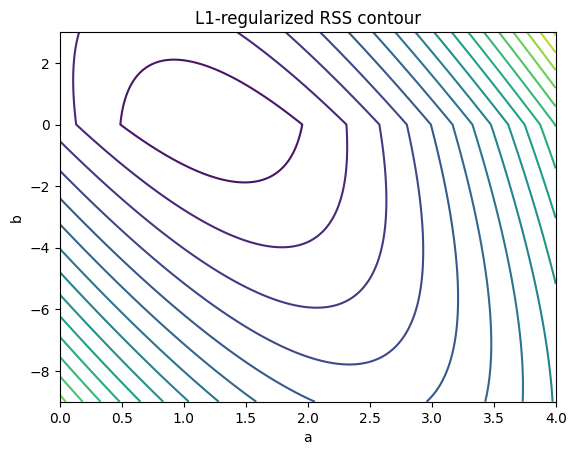

In [273]:
alpha = 100

# L1-regularized objective
def fL1(a, b, X, Y, alpha):
    return rss2(a, b, X, Y) + alpha * (abs(a) + abs(b))

# Grid (match MATLAB exactly)
a_vals = np.arange(a0 - 2, a0 + 2 + 0.01, 0.01)
b_vals = np.arange(b0 - 6, b0 + 6 + 0.04, 0.04)

A, B = np.meshgrid(a_vals, b_vals)

# Evaluate function
Z = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        Z[i, j] = fL1(A[i, j], B[i, j], X, Y, alpha)

# Contour plot (MATLAB plot3d(..., false))
plt.figure()
plt.contour(A, B, Z, levels=20)

plt.xlabel('a')
plt.ylabel('b')
plt.title('L1-regularized RSS contour')

plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^1}(a,b) 
&= \left [ \frac{\partial RSS_{L^1}(a,b)}{\partial a}, \frac{\partial RSS_{L^1}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +\alpha\ \text{sign}(a), \frac{\partial RSS(a,b)}{\partial b}+\alpha\ \text{sign}(b)\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\   \text{sign}(b)\right ]^T 
\end{aligned}
$$

[[ 2.         -3.        ]
 [ 1.97308785 -2.99194282]
 [ 1.9481593  -2.98360572]
 ...
 [ 1.22197373  0.00378852]
 [ 1.22192792 -0.00560358]
 [ 1.22198896  0.0050236 ]]


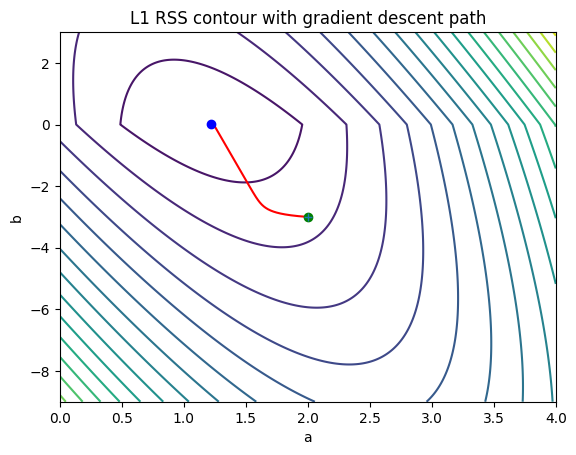

In [274]:
def grad_rss2_L1(a, b, X, Y, alpha):
    da, db = grad_rss2(a, b, X, Y)
    da += alpha * np.sign(a)
    db += alpha * np.sign(b)
    return da, db

K = 5000
learning_eps = 0.0001

ffL1 = lambda a, b: grad_rss2_L1(a, b, X, Y, alpha)

as_L1, bs_L1 = grad_desc_generic(K, a0, b0, learning_eps, ffL1, True)

print(np.column_stack((as_L1, bs_L1)))

plt.figure()
plt.contour(A, B, Z, levels=20)
plt.plot(as_L1, bs_L1, 'r-')
plt.plot(as_L1[0], bs_L1[0], 'go')
plt.plot(as_L1[K], bs_L1[K], 'bo')
plt.plot(a0, b0, '+')
plt.xlabel('a')
plt.ylabel('b')
plt.title('L1 RSS contour with gradient descent path')
plt.show()

L1 a=1.22 b=0.01 loss=1420.65


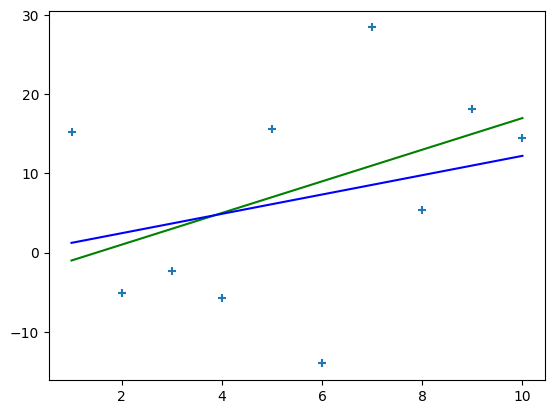

In [275]:
a_L1 = as_L1[K]
b_L1 = bs_L1[K]

print(f"L1 a={a_L1:.2f} b={b_L1:.2f} loss={rss2(a_L1, b_L1, X, Y):.2f}")

plt.figure()
plt.scatter(X, Y, marker='+')
plt.plot(X, a0 * X + b0, color='g')
plt.plot(X, a_L1 * X + b_L1, color='b')
plt.show()

## 4. Regularization with the $L^2$ Norm constraint

### Constrained Optimization (L2)

We now solve:

\[
\min RSS(a,b) \quad \text{s.t.} \quad a^2 + b^2 = c
\]

This is handled using Lagrange multipliers:

\[
\mathcal{L}(a,b,\alpha) = RSS + \alpha(a^2 + b^2 - c)
\]

This formulation enforces a hard constraint on the parameter magnitude.s

The the gradient of is (now unconstraint) problem is:

$$
\begin{aligned}
\nabla \mathcal{L}^2(a,b,\alpha) 
&= \left [ \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial a}, \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial b}, \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial \alpha} \right ]^T\\
&= \left [ 
\frac{\partial RSS(a,b)}{\partial a} + 2\alpha a, 
\frac{\partial RSS(a,b)}{\partial b} + 2\alpha b, 
a^2 + b^2 -c\right ]^T\\
&= \left [
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a, 
-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b, 
a^2 + b^2 -c\right ]^T 
\end{aligned}
$$

In [276]:
def grad_rss3e(a, b, alpha, c, X, Y):
    residuals = Y - (a * X + b)

    grad_a = -2 * np.sum(X * residuals) + 2 * alpha * a
    grad_b = -2 * np.sum(residuals) + 2 * alpha * b
    grad_alpha = a**2 + b**2 - c

    return np.array([grad_a, grad_b, grad_alpha])

In [277]:
def grad_desc_rss3e(K, a0, b0, alpha0, learning_eps, f_orig, f, ff, verbose):
    as_vals = np.zeros(K + 1)
    bs_vals = np.zeros(K + 1)
    alphas = np.zeros(K + 1)

    as_vals[0] = a0
    bs_vals[0] = b0
    alphas[0] = alpha0

    for k in range(K):
        grad_w = ff(as_vals[k], bs_vals[k], alphas[k])
        grad_a, grad_b, grad_alpha = grad_w

        as_vals[k + 1] = as_vals[k] - learning_eps * grad_a
        bs_vals[k + 1] = bs_vals[k] - learning_eps * grad_b
        alphas[k + 1] = alphas[k] - learning_eps * grad_alpha

        if verbose:
            plt.plot(
                [as_vals[k], as_vals[k + 1]],
                [bs_vals[k], bs_vals[k + 1]]
            )

    grad_w = ff(as_vals[K], bs_vals[K], alphas[K])
    print("grad_w =", grad_w)

    ffinal = lambda a, b: f(a, b, alphas[K])

    if verbose:
        alow = min(np.min(as_vals), a0 - 2)
        ahigh = max(np.max(as_vals), a0 + 2)
        blow = min(np.min(bs_vals), b0 - 3)
        bhigh = max(np.max(bs_vals), b0 + 3)

        A, B = np.meshgrid(
            np.arange(alow, ahigh + 0.1, 0.1),
            np.arange(blow, bhigh + 0.4, 0.4)
        )

        Z = np.zeros_like(A, dtype=float)
        for i in range(A.shape[0]):
            for j in range(A.shape[1]):
                Z[i, j] = f_orig(A[i, j], B[i, j])

        plt.contour(A, B, Z, levels=20)

    return as_vals, bs_vals, alphas

grad_w = [ 4.87446666e-02 -4.44257593e-04 -2.39416992e+01]


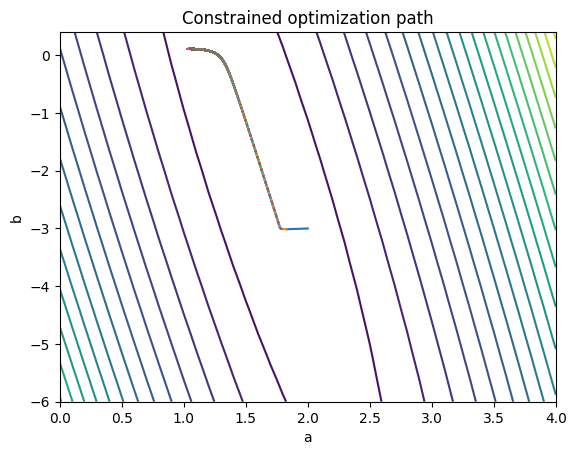

In [278]:
K = 5000
learning_eps = 0.001

# set randomly as a constraint
c = (2 + 1)**2 + (3 + 1)**2

fL2c = lambda a, b, alpha: rss2(a, b, X, Y) + alpha * (a**2 + b**2 - c)
ffL2c = lambda a, b, alpha: grad_rss3e(a, b, alpha, c, X, Y)

alpha0 = 1

plt.figure()
as_vals, bs_vals, alphas = grad_desc_rss3e(
    K, a0, b0, alpha0, learning_eps,
    lambda a, b: rss2(a, b, X, Y),   # f_orig
    fL2c,                             # f
    ffL2c,                            # ff
    True
)

plt.xlabel('a')
plt.ylabel('b')
plt.title('Constrained optimization path')
plt.show()

L2 constraint: a=1.02 b=0.11 alpha=117.93 loss=1452.89; a^2 + b^2 = 1.06; c=25.00


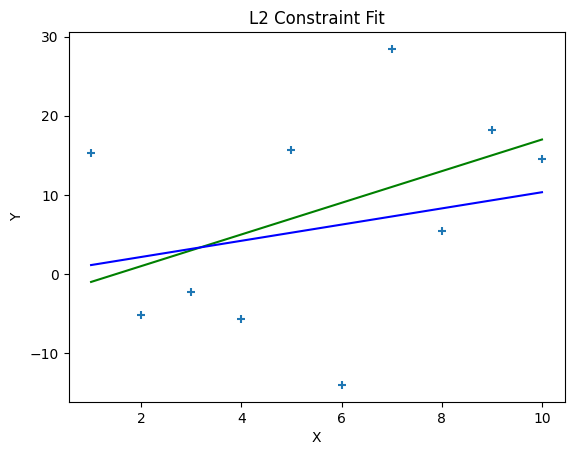

In [279]:
a_c = as_vals[K]
b_c = bs_vals[K]
alpha_c = alphas[K]

print(
    f"L2 constraint: a={a_c:.2f} b={b_c:.2f} alpha={alpha_c:.2f} "
    f"loss={rss2(a_c, b_c, X, Y):.2f};",
    end=""
)
print(
    f" a^2 + b^2 = {a_c**2 + b_c**2:.2f}; c={c:.2f}"
)

plt.figure()
plt.scatter(X, Y, marker='+')

# True line (green)
plt.plot(X, a0 * X + b0, color='g')

# Constrained solution (blue)
plt.plot(X, a_c * X + b_c, color='b')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('L2 Constraint Fit')

plt.show()

This does not seem to converge to a minumum: $a^2 + b^2 = 1 \neq c=25$. The problem is that when using Lagrange multipliers, the critical points don't occur at local minima of the Lagrangian - they occur at saddle points instead. Since the gradient descent algorithm is designed to find local minima, it fails to converge when we give it a problem with constraints.

Therefore, we optimize for the squared magnitude of the gradient, which is the sum of the squares of the partial derivatives. This is a transformation of the constraint problem such that the critical points occur at local minima. Details [here](https://en.wikipedia.org/wiki/Lagrange_multiplier#Example_4:_Numerical_optimization).

In our case the squared magnitude $M^2$ of the gradient $\nabla \mathcal{L}^2(a,b,\alpha)$ is:

$$
M^2(a,b,\alpha) = 
\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)^2 +
\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)^2 +
\left ( \alpha (a^2 + b^2 -c) \right)^2 
$$ 

and its gradient is:

$$
\begin{align}
\nabla M^2(a,b,\alpha) &= 
\begin{bmatrix}
2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)\left (-2 \sum_{i=1}^{n}-x_i^2+ 2 \alpha \right) 
+ 2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)\left (-2 \sum_{i=1}^{n}-x_i \right) 
    + 4\alpha^2 a(a^2 + b^2 -c) \\
2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)\left (-2 \sum_{i=1}^{n} -x_i \right) 
+ 2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)\left (-2 \sum_{i=1}^{n} -1 + 2 \alpha \right) 
+ 4\alpha^2 b(a^2 + b^2 -c) \\
-8a \left (\sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right) 
-8b \left (\sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)
+2\alpha (a^2 + b^2 -c )^2
\end{bmatrix}
\\
&= 
\begin{bmatrix}
8\left (-\sum_{i=1}^{n}(y_i- a x_i-b)x_i + \alpha a \right)\left (\sum_{i=1}^{n}x_i^2+\alpha \right) 
+ 8\left (-\sum_{i=1}^{n}(y_i- a x_i-b) + \alpha b \right)\left (\sum_{i=1}^{n}x_i \right) 
    + 4\alpha^2 a(a^2 + b^2 -c) \\
8\left (-\sum_{i=1}^{n}(y_i- a x_i-b)x_i + \alpha a \right)\left (\sum_{i=1}^{n} x_i \right) 
+ 8\left (-\sum_{i=1}^{n}(y_i- a x_i-b) + \alpha b \right)\left (\sum_{i=1}^{n} 1 + \alpha \right) 
+ 4\alpha^2 b(a^2 + b^2 -c) \\
-8a \left (\sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right) 
-8b \left (\sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)
+2\alpha (a^2 + b^2 -c )^2
\end{bmatrix}
\end{align}$$

We don't want to further simplify this gradient nor use it to implement the optimization with gradient descent. Both is (error prone but) straight forward. 

See the "Constraint Optimization" notebook where we exercise this with a simpler optimization problem.

### 4.2 Regularization with the $L^2$ Norm inequality constraint

### Slack Variable Formulation

To relax the constraint, we introduce a slack variable:

$$
a^2 + b^2 + s^2 = c
$$

This allows:
- soft constraint satisfaction
- improved numerical stability
- better optimization behavior

In [280]:
import numpy as np

def grad_rss3(a, b, alpha, s, c, X, Y):
    grad_a = 0.0
    grad_b = 0.0

    n = len(X)

    for i in range(n):
        tmp = Y[i] - a * X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp

    grad_a = -2 * grad_a + 2 * alpha * a
    grad_b = -2 * grad_b + 2 * alpha * b
    grad_alpha = a**2 + b**2 - c + s**2
    grad_s = 2 * alpha * s

    return np.array([grad_a, grad_b, grad_alpha, grad_s])

In [281]:
def grad_desc_rss3(K, a0, b0, alpha0, s0, learning_eps, f_orig, f, ff, verbose):
    as_vals = np.zeros(K + 1)
    bs_vals = np.zeros(K + 1)
    alphas = np.zeros(K + 1)
    ss = np.zeros(K + 1)

    as_vals[0] = a0
    bs_vals[0] = b0
    alphas[0] = alpha0
    ss[0] = s0

    for k in range(K):
        grad_a, grad_b, grad_alpha, grad_s = ff(
            as_vals[k], bs_vals[k], alphas[k], ss[k]
        )

        as_vals[k + 1] = as_vals[k] - learning_eps * grad_a
        bs_vals[k + 1] = bs_vals[k] - learning_eps * grad_b
        alphas[k + 1] = alphas[k] - learning_eps * grad_alpha
        ss[k + 1] = ss[k] - learning_eps * grad_s

        if verbose:
            plt.plot(
                [as_vals[k], as_vals[k + 1]],
                [bs_vals[k], bs_vals[k + 1]]
            )

    grad_w = ff(as_vals[K], bs_vals[K], alphas[K], ss[K])
    print("grad_w =", grad_w)

    ffinal = lambda a, b: f(a, b, alphas[K], ss[K])

    if verbose:
        alow = min(np.min(as_vals), a0 - 2)
        ahigh = max(np.max(as_vals), a0 + 2)
        blow = min(np.min(bs_vals), b0 - 3)
        bhigh = max(np.max(bs_vals), b0 + 3)

        A, B = np.meshgrid(
            np.arange(alow, ahigh + 0.1, 0.1),
            np.arange(blow, bhigh + 0.4, 0.4)
        )

        Z = np.zeros_like(A, dtype=float)
        for i in range(A.shape[0]):
            for j in range(A.shape[1]):
                Z[i, j] = f_orig(A[i, j], B[i, j])

        plt.contour(A, B, Z, levels=20)

    return as_vals, bs_vals, alphas, ss

grad_w = [ 1.15860738e-01 -2.94714267e-01 -2.33035667e+01  7.78816162e-05]


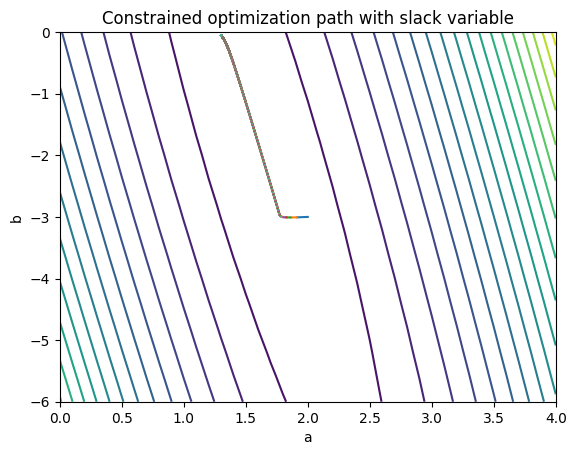

In [282]:
K = 1500
learning_eps = 0.0005

# set randomly as a constraint
c = (2 + 1)**2 + (3 + 1)**2

fL2c = lambda a, b, alpha, s: rss2(a, b, X, Y) + alpha * (a**2 + b**2 - c + s**2)
ffL2c = lambda a, b, alpha, s: grad_rss3(a, b, alpha, s, c, X, Y)

alpha0 = 1
s0 = 1

plt.figure()
as_vals, bs_vals, alphas, ss = grad_desc_rss3(
    K, a0, b0, alpha0, s0, learning_eps,
    lambda a, b: rss2(a, b, X, Y),   # f_orig
    fL2c,                             # f
    ffL2c,                            # ff
    True
)

plt.xlabel('a')
plt.ylabel('b')
plt.title('Constrained optimization path with slack variable')
plt.show()

L2 constraint: a=1.30 b=-0.05 alpha=17.19 s=0.00 loss=1415.06; a^2 + b^2 = 1.70 < c=25.00


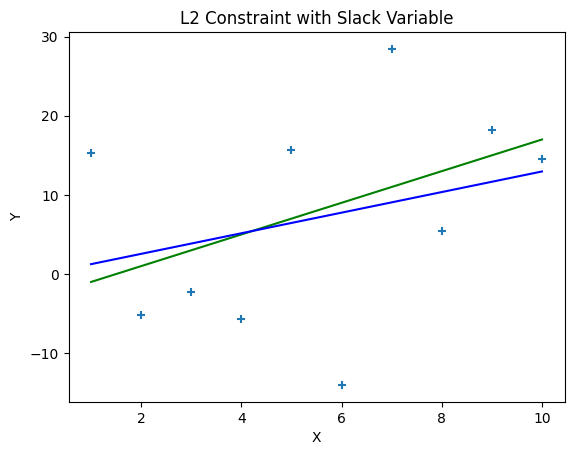

In [283]:
a_c = as_vals[K]
b_c = bs_vals[K]
alpha_c = alphas[K]
s_c = ss[K]

print(
    f"L2 constraint: a={a_c:.2f} b={b_c:.2f} alpha={alpha_c:.2f} s={s_c:.2f} "
    f"loss={rss2(a_c, b_c, X, Y):.2f};",
    end=""
)
print(
    f" a^2 + b^2 = {a_c**2 + b_c**2:.2f} < c={c:.2f}"
)

plt.figure()
plt.scatter(X, Y, marker='+')

# True line (green)
plt.plot(X, a0 * X + b0, color='g')

# Constrained (with slack) fit (blue)
plt.plot(X, a_c * X + b_c, color='b')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('L2 Constraint with Slack Variable')

plt.show()

Again, gradient descent does not seem to converge well since the critical points of Lagrangians occur at saddle points. Therefore, we solve the constraint optimization problem with the Karush–Kuhn–Tucker (KKT) approach. We need to check the KKT conditions:

$$
\begin{aligned}
\frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial a} &=0 \ \ \ \ \ (1)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2\alpha a&=0\\
\frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial b} &=0 \ \ \ \ \ (2)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b) +2\alpha b&=0 \\
\alpha (a^2 + b^2 - c) &=0 \ \ \ \ \ (3)
\end{aligned}
$$

We need to distinguish two cases for (3): 
- $\alpha = 0$ and $a^2 + b^2 - c < 0$, i.e., the constraint is inactive, (3a) 
- $\alpha > 0$ and $a^2 + b^2 - c = 0$, i.e., the constraint is active, (3b) 

In [284]:
# Assuming a_orig and b_orig already computed earlier

# same constraint definition
c = (2 + 1)**2 + (3 + 1)**2

# equivalent of (a_orig)^2+(b_orig)^2-c
constraint_diff = a_orig**2 + b_orig**2 - c

print(f"a_orig = {a_orig:.4f}, b_orig = {b_orig:.4f}")
print(f"a^2 + b^2 = {a_orig**2 + b_orig**2:.4f}")
print(f"c = {c:.4f}")
print(f"difference = {constraint_diff:.4f}")

a_orig = 1.6226, b_orig = -1.8959
a^2 + b^2 = 6.2273
c = 25.0000
difference = -18.7727


In [285]:
import sympy as sp
# Symbols
a, b, alpha = sp.symbols('a b alpha')

# Convert data to sympy objects
X_sym = sp.Matrix(X)
Y_sym = sp.Matrix(Y)
eins = sp.ones(len(X), 1)

# Residual
residual = Y_sym - a * X_sym - b * eins

# Equations
eqn1 = -2 * (residual.T * X_sym)[0] + 2 * alpha * a
eqn2 = -2 * (residual.T * eins)[0] + 2 * alpha * b
eqn3 = a**2 + b**2 - c

# Solve system
solutions = sp.solve([eqn1, eqn2, eqn3], [a, b, alpha], dict=True)

solutions

[{a: -4.95046415773569 - 2.5410988417629e-21*I,
  alpha: -497.929447391764 + 1.77853496949478e-30*I,
  b: -0.702071665127041 - 4.2351647362715e-22*I},
 {a: 0.648625997885638 + 3.17637355220363e-22*I,
  alpha: -3.01871180231512 + 2.38900050202741e-30*I,
  b: 4.95774992459955 + 8.470329472543e-22*I},
 {a: 2.01187335000622 + 1.27054942088145e-21*I,
  alpha: -1.1811639345665 + 1.74504919137773e-30*I,
  b: -4.57737540775658 - 1.6940658945086e-21*I},
 {a: 4.94697794106103 + 2.5410988417629e-21*I,
  alpha: -287.870676871354 - 5.91258466289991e-30*I,
  b: 0.726229475204369 + 2.11758236813575e-22*I}]

In [286]:
# Symbols
a, b, alpha = sp.symbols('a b alpha')

# Convert data
X_sym = sp.Matrix(X)
Y_sym = sp.Matrix(Y)
eins = sp.ones(len(X), 1)

# Residual
residual = Y_sym - a * X_sym - b * eins

# Equations
eqn1 = -2 * (residual.T * X_sym)[0] + 2 * alpha * a
eqn2 = -2 * (residual.T * eins)[0] + 2 * alpha * b
eqn3 = a**2 + b**2 - c

# Numerical solve (requires initial guess)
sol = sp.nsolve(
    [eqn1, eqn2, eqn3],
    [a, b, alpha],
    [a0, b0, 1]   # initial guess (similar role to MATLAB vpasolve default behavior)
)

# Extract values
a_hat = float(sol[0])
b_hat = float(sol[1])
alpha_hat = float(sol[2])

print("a_hat =", a_hat)
print("b_hat =", b_hat)
print("alpha_hat =", alpha_hat)

a_hat = 2.0118733500062222
b_hat = -4.577375407756582
alpha_hat = -1.181163934566484


L2 constraint: a=2.01 b=-4.58 alpha=-1.18 loss=1421.91 feasible: a^2 + b^2 = 25.00 == c=25.00


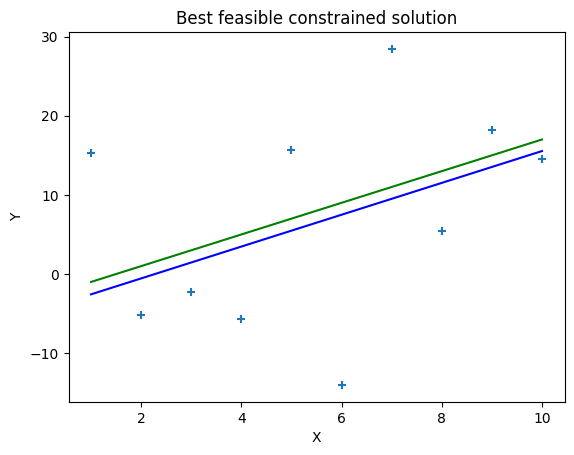

In [287]:
try:
    # If multiple solutions (list-like)
    a_hats = np.array([float(s[0]) for s in sol])
    b_hats = np.array([float(s[1]) for s in sol])
    alpha_hats = np.array([float(s[2]) for s in sol])
except TypeError:
    # If single solution (nsolve typical case)
    a_hats = np.array([float(sol[0])])
    b_hats = np.array([float(sol[1])])
    alpha_hats = np.array([float(sol[2])])

# --- current cell logic ---
min_rss = np.inf
arg_min = 0

for i in range(len(a_hats)):
    a_hat = a_hats[i]
    b_hat = b_hats[i]
    alpha_hat = alpha_hats[i]

    rss = rss2(a_hat, b_hat, X, Y)

    if rss < min_rss:
        min_rss = rss
        arg_min = i

    print(
        f"L2 constraint: a={a_hat:.2f} b={b_hat:.2f} "
        f"alpha={alpha_hat:.2f} loss={rss:.2f}",
        end=""
    )
    print(
        f" feasible: a^2 + b^2 = {a_hat**2 + b_hat**2:.2f} == c={c:.2f}"
    )

# --- plotting (same variables as earlier cells) ---
plt.figure()
plt.scatter(X, Y, marker='+')

# True line
plt.plot(X, a0 * X + b0, color='g')

# Best constrained solution
plt.plot(X, a_hats[arg_min] * X + b_hats[arg_min], color='b')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Best feasible constrained solution')
plt.show()

## Regularization with the $L^1$ Norm constraint

### L1 Constraint

We now replace the circular constraint with a diamond-shaped one:

$$
|a| + |b| = c
$$

This changes the geometry of the solution:
- constraint region becomes non-smooth
- solutions tend to lie on corners
- promotes sparsity-like behavior

In [288]:
import numpy as np

def grad_rss4(a, b, alpha, s, c, X, Y):
    grad_a = 0.0
    grad_b = 0.0

    n = len(X)

    for i in range(n):
        tmp = Y[i] - a * X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp

    # L1-style subgradient (sign)
    grad_a = -2 * grad_a + alpha * np.sign(a)
    grad_b = -2 * grad_b + alpha * np.sign(b)

    # constraint with slack
    grad_alpha = abs(a) + abs(b) - c + s**2
    grad_s = 2 * alpha * s

    return np.array([grad_a, grad_b, grad_alpha, grad_s])

grad_w = [ 0.3577277  -2.4677581  -2.99506915  1.6714151 ]


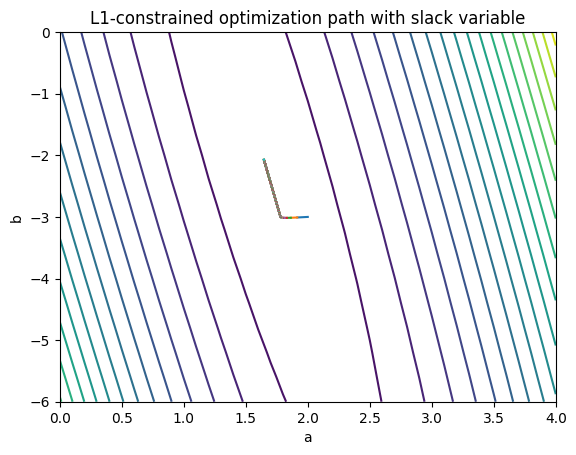

In [289]:
K = 500
learning_eps = 0.0005
c = (2 + 1) + (3 + 1)

fL1c = lambda a, b, alpha, s: rss2(a, b, X, Y) + alpha * (abs(a) + abs(b) - c + s**2)
ffL1c = lambda a, b, alpha, s: grad_rss4(a, b, alpha, s, c, X, Y)

plt.figure()
as_vals, bs_vals, alphas, ss = grad_desc_rss3(
    K, a0, b0, alpha0, s0, learning_eps,
    lambda a, b: rss2(a, b, X, Y),   # f_orig
    fL1c,                             # f
    ffL1c,                            # ff
    True
)

plt.xlabel('a')
plt.ylabel('b')
plt.title('L1-constrained optimization path with slack variable')
plt.show()

L1 constraint: a=1.65 b=-2.07 alpha=1.55 s=0.54 loss=1406.56 |a| + |b| = 3.72 < c=7.00


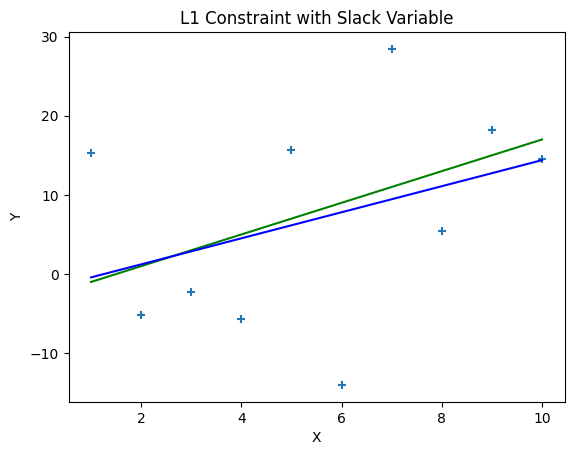

In [290]:
a_c = as_vals[K]
b_c = bs_vals[K]
alpha_c = alphas[K]
s_c = ss[K]

print(
    f"L1 constraint: a={a_c:.2f} b={b_c:.2f} alpha={alpha_c:.2f} s={s_c:.2f} "
    f"loss={rss2(a_c, b_c, X, Y):.2f}",
    end=""
)
print(
    f" |a| + |b| = {abs(a_c) + abs(b_c):.2f} < c={c:.2f}"
)

plt.figure()
plt.scatter(X, Y, marker='+')

# True line (green)
plt.plot(X, a0 * X + b0, color='g')

# L1-constrained (with slack) fit (blue)
plt.plot(X, a_c * X + b_c, color='b')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('L1 Constraint with Slack Variable')

plt.show()

Gradient descent does not seem to converge well. Even the constraint is violated. Therefore, we solve the constraint optimization problem with the Karush–Kuhn–Tucker (KKT) approach. Again, we need to check the KKT conditions:

$$
\begin{aligned}
\frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial a} &=0 \ \ \ \ \ (1)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a) &=0\\
\frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial b} &=0 \ \ \ \ \ (2)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\ \text{sign}(b) &=0 \\
\alpha (|a| + |b| - c) &=0 \ \ \ \ \ (3)
\end{aligned}
$$

We need to distinguish two cases for (3): 
- $\alpha = 0$ and $|a| + |b| - c < 0$, i.e., the constraint is inactive, (3a) 
- $\alpha > 0$ and $|a| + |b| - c = 0$, i.e., the constraint is active, (3b) 

In [291]:
c = (2 + 1) + (3 + 1)

constraint_diff = abs(a_orig) + abs(b_orig) - c

print(f"|a_orig| + |b_orig| = {abs(a_orig) + abs(b_orig):.4f}")
print(f"c = {c:.4f}")
print(f"difference = {constraint_diff:.4f}")

|a_orig| + |b_orig| = 3.5185
c = 7.0000
difference = -3.4815


In [292]:
# Symbols
a, b, alpha = sp.symbols('a b alpha')

# Data as sympy objects
X_sym = sp.Matrix(X)
Y_sym = sp.Matrix(Y)
eins = sp.ones(len(X), 1)

# Residual
residual = Y_sym - a * X_sym - b * eins

# Equations (same structure as MATLAB)
eqn1 = -2 * (residual.T * X_sym)[0] + alpha * sp.sign(a)
eqn2 = -2 * (residual.T * eins)[0] + alpha * sp.sign(b)
eqn3 = sp.Abs(a) + sp.Abs(b) - c

In [293]:

# Symbols
a, b, alpha = sp.symbols('a b alpha')

# Rebuild the equations for the sign case a > 0, b < 0
X_sym = sp.Matrix(X)
Y_sym = sp.Matrix(Y)
eins = sp.ones(len(X), 1)

residual = Y_sym - a * X_sym - b * eins

eqn1_case = -2 * (residual.T * X_sym)[0] + alpha
eqn2_case = -2 * (residual.T * eins)[0] - alpha
eqn3_case = a - b - c   # |a| + |b| = a + (-b)

sol = sp.nsolve(
    [eqn1_case, eqn2_case, eqn3_case],
    [a, b, alpha],
    [a0, b0, 1]
)

a_hat = float(sol[0])
b_hat = float(sol[1])
alpha_hat = float(sol[2])

print("a_hat =", a_hat)
print("b_hat =", b_hat)
print("alpha_hat =", alpha_hat)
print("feasible sign case:", a_hat > 0, b_hat < 0)

a_hat = 2.070742873273724
b_hat = -4.9292571267262755
alpha_hat = -11.3752483131959
feasible sign case: True True


L1 constraint: a=2.07 b=-4.93 alpha=-11.38 loss=1426.29 |a| + |b| = 7.00 == c=7.00


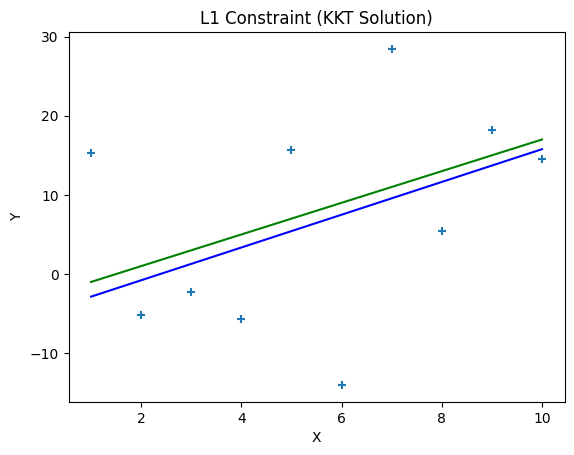

In [294]:
print(
    f"L1 constraint: a={a_hat:.2f} b={b_hat:.2f} alpha={alpha_hat:.2f} "
    f"loss={rss2(a_hat, b_hat, X, Y):.2f}",
    end=""
)
print(
    f" |a| + |b| = {abs(a_hat) + abs(b_hat):.2f} == c={c:.2f}"
)

plt.figure()
plt.scatter(X, Y, marker='+')

# True line (green)
plt.plot(X, a0 * X + b0, color='g')

# L1-constrained solution (blue)
plt.plot(X, a_hat * X + b_hat, color='b')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('L1 Constraint (KKT Solution)')

plt.show()

### Multivariate Linear Regression

We extend the model to:

\[
y = a_1 x_1 + a_2 x_2 + b
\]

This introduces:
- a higher-dimensional parameter space
- matrix-based formulation
- the same principles as before (RSS, regularization, constraints)

### Multivariate Linear Regression

We extend the model to:

\[
y = a_1 x_1 + a_2 x_2 + b
\]

This introduces:
- a higher-dimensional parameter space
- matrix-based formulation
- the same principles as before (RSS, regularization, constraints)

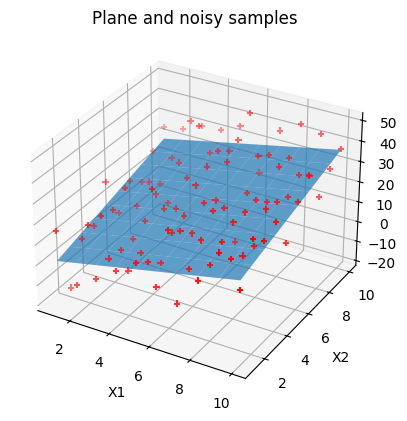

In [295]:
# Equivalent of:
# XX = fliplr(fullfact([N N]));
levels = np.arange(1, N + 1)
X2_grid, X1_grid = np.meshgrid(levels, levels)   # arranged to match fliplr(fullfact([N N]))
XX = np.column_stack((X1_grid.ravel(), X2_grid.ravel()))

a10 = 2
a20 = 2
b0 = -3

X1 = XX[:, 0]
X2 = XX[:, 1]

f0 = lambda x1, x2: a10 * x1 + a20 * x2 + b0
f = lambda x1, x2, r: a10 * x1 + a20 * x2 + b0 + r

# Equivalent of normrnd(0,10,1,N*N).'
R = np.random.normal(0, 10, N * N)

# Equivalent of arrayfun(f,X1,X2,R)
Y = np.array([f(x1, x2, r) for x1, x2, r in zip(X1, X2, R)])

# Equivalent of [A,B] = meshgrid(1:N,1:N)
A, B = np.meshgrid(np.arange(1, N + 1), np.arange(1, N + 1))

# Surface plot + scatter3
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Z0 = f0(A, B)
ax.plot_surface(A, B, Z0, alpha=0.7)
ax.scatter(X1, X2, Y, c='r', marker='+')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
plt.title('Plane and noisy samples')

plt.show()

Let's check the error $RSS_0$ for the initial parameters, learn new parameters from the generated data with linear regression minimizing $RSS$, and then check again this new error.

* $\verb|XS = [ones(N*N,1), XX]|$ Adds a bias term (column of 1's) to the design matrix XX. This makes XS a matrix of size (N*N*3), where the first column handles the intercept b0, and the rest are our features a10 and a20.

* $\verb|w0 = [b0, a10, a20].'|$ is the weight vector for checking an initial guess.

* $\verb|RSS0 = (Y - XS * w0).' * (Y - XS * w0)|$ computes the Residual Sum of Squares (RSS) for w0.

* $\verb|w = inv(XS.' * XS) * XS.' * Y|$ is the closed-form solution for linear regression: $w=(X^T X)^{−1} X^T Y$ minimizes the Mean Squared Error (or equivalently, the RSS), giving the best-fitting line/hyperplane in the least-squares sense.

In [296]:
# Design matrix: [1, x1, x2]
XS = np.column_stack((np.ones(N * N), XX))

# True parameter vector
w0 = np.array([b0, a10, a20])

# RSS with true parameters
RSS0 = (Y - XS @ w0).T @ (Y - XS @ w0)

# Closed-form least squares solution
w = np.linalg.inv(XS.T @ XS) @ XS.T @ Y

# RSS with fitted parameters
RSS = (Y - XS @ w).T @ (Y - XS @ w)

print("w0 =", w0)
print("RSS0 =", RSS0)
print("w =", w)
print("RSS =", RSS)

w0 = [-3  2  2]
RSS0 = 6941.233444142008
w = [-6.44126885  2.15797407  2.60283601]
RSS = 6565.597983767188


### Underdetermined System

When using too few data points, the system becomes:

- rank-deficient
- not invertible
- unstable

This highlights the need for:
- regularization (ridge)
- pseudoinverse / least-squares solutions

In [297]:
# Subsample: first N rows
uXX = XX[:N, :]
uY = Y[:N]

# Design matrix
uXS = np.column_stack((np.ones(N), uXX))

# RSS with true parameters
RSS0 = (uY - uXS @ w0).T @ (uY - uXS @ w0)

# Robust least-squares estimate
w = np.linalg.lstsq(uXS, uY, rcond=None)[0]

print("RSS0 =", RSS0)
print("w =", w)
print("rank(uXS) =", np.linalg.matrix_rank(uXS))

RSS0 = 1027.04063739952
w = [-1.7524183  -1.7524183   2.14708232]
rank(uXS) = 2


### Ridge Regression Fix

### Ridge Regression Fix

Adding:

$
\alpha I
$

makes the system invertible:

$
(X^T X + \alpha I)^{-1} X^T y
$

This stabilizes the solution and prevents singular matrix errors.

In [298]:
alpha = 0.1
I = np.eye(3)

w = np.linalg.inv(uXS.T @ uXS + alpha * I) @ uXS.T @ uY
RSS = (uY - uXS @ w).T @ (uY - uXS @ w)

print("w =", w)
print("RSS =", RSS)

w = [-1.70551259 -1.70551259  2.13312663]
RSS = 996.5146548072553


## Conclusion

In this notebook, we explored multiple approaches to linear regression and optimization:

- OLS provides a closed-form solution but can be unstable with limited data
- Gradient descent allows iterative optimization and visualization
- L2 regularization stabilizes solutions by shrinking parameters
- L1 regularization introduces sparsity and non-smooth optimization
- Constrained optimization enforces explicit parameter bounds
- Slack variables relax constraints for better numerical behavior
- Multivariate regression generalizes all concepts to higher dimensions

A key takeaway is that different formulations lead to different geometries:

- L2 → circular constraints
- L1 → diamond-shaped constraints
- constraints vs penalties → hard vs soft control

These choices directly affect:
- stability
- interpretability
- optimization behavior